## PSILO

In [16]:
#Libraries 
import os
import time
import math
import numpy as np
import pandas as pd
import scipy
import scipy.signal as spsg
from scipy import stats
from scipy.io import loadmat
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.cluster import KMeans
from scipy.spatial.distance import cityblock
from data.labels_brain import reorder_matrix
from tqdm import tqdm
from scipy.stats import pearsonr


#random.seed(42)

### Reading Data

In [2]:
# Read the data
data_path= "C:/Users/diego/Desktop/phase_coherance_consciousness/data"

#Some of the data is corrupted, we chose manually the patiens we want to read.
num_patients=[0,1,2,3,4,6,7,8,9,10,12,13,14]
num=len(num_patients)

data_PSILO = os.path.join(data_path, "PSILO_TS_FC.mat")
data_PSILO = loadmat(data_PSILO)
data_PSILO = data_PSILO["DataCorrel"].flatten()

#Some of the data is corrupted, we chose manually the patiens we want to read.
#num_patients=range(data_PSILO["TS_Psilo"].shape[0])
num_patients=[0,1,2,3,4,6,7,8,9,10,12,13,14]
num=len(num_patients)

PSILOACAT = np.hstack([data_PSILO["TS_Psilo"][i] for i in num_patients])
PSILOPCAT = np.hstack([data_PSILO["TS_PCB"][i] for i in num_patients])

PSILO_Signals = np.hstack((PSILOACAT, PSILOPCAT))
print(f"PSILO concatenated signals: {PSILO_Signals.shape} from {data_PSILO.shape[0]} patients.")

PSILO concatenated signals: (90, 2487) from 15 patients.


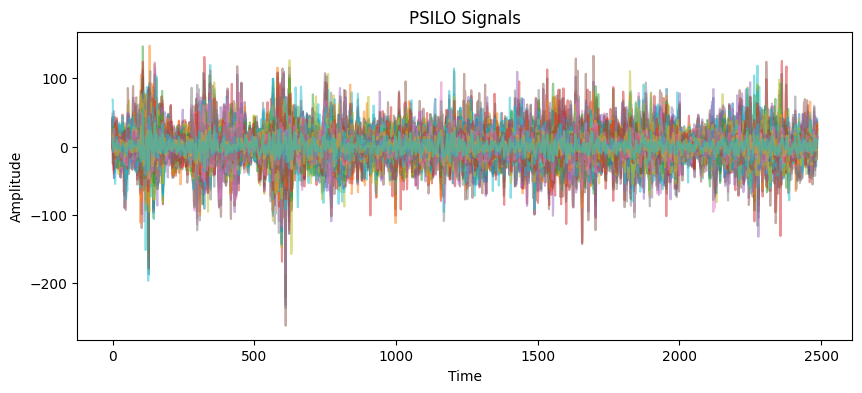

In [3]:
# Initial visualization of the Bold Signals (Time Series)
plt.figure(figsize=(10, 4))
plt.plot(PSILO_Signals.T, alpha=0.5)
plt.title("PSILO Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Extract Size and Features

In [4]:
#Number of Regions and Total Time
ROI,time_length = PSILO_Signals.shape

# Loop over each region to extract the lenght of each signal.
Time_per_subj = np.zeros(ROI, dtype=int)
for i in range(ROI):
    Time_per_subj[i] = len(PSILO_Signals[i])


print(f" Number of Regions (ROI): {ROI} \n Total Time: {time_length}")

 Number of Regions (ROI): 90 
 Total Time: 2487


### Import the Connectoma 

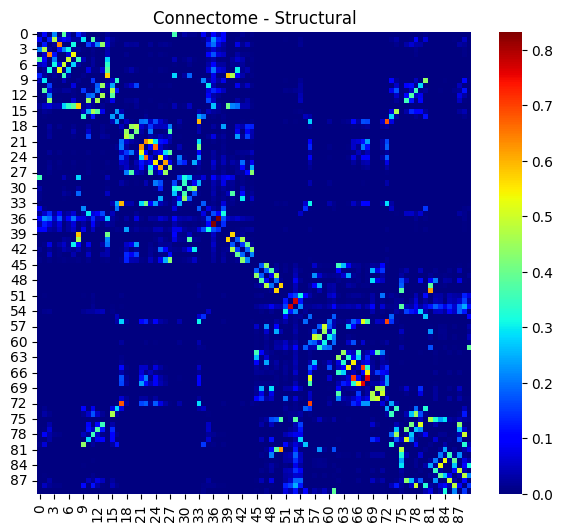

In [5]:
# Import the atlas
data_connectome = os.path.join(data_path, "./structural.mat")
CC = loadmat(data_connectome)['A']

# Plot it
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(CC, cmap='jet',cbar=True, ax=ax)
ax.set_title(f"Connectome - Structural")
plt.show()

In [6]:
CC_reordered, new_labels, new_group_labels = reorder_matrix(connectivity_matrix=CC)
CC_reordered = pd.DataFrame(CC_reordered, index=new_labels, columns=new_labels)
CC_reordered["Group"] = new_group_labels
CC_reordered.head()

,Cingulum_Ant_L,Cingulum_Ant_R,Cingulum_Mid_L,Cingulum_Mid_R,Cingulum_Post_L,Cingulum_Post_R,Frontal_Sup_L,Frontal_Sup_R,Frontal_Sup_Orb_L,Frontal_Sup_Orb_R,...,Temporal_Sup_R,Temporal_Pole_Sup_L,Temporal_Pole_Sup_R,Temporal_Mid_L,Temporal_Mid_R,Temporal_Pole_Mid_L,Temporal_Pole_Mid_R,Temporal_Inf_L,Temporal_Inf_R,Group
Cingulum_Ant_L,0.000000,0.364909,0.447285,0.003396,0.000000,0.000000,0.0,0.002057,0.00000,0.009036,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Ant_R,0.364909,0.000000,0.172070,0.006958,0.000000,0.000000,0.0,0.000000,0.00084,0.021055,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Mid_L,0.447285,0.172070,0.000000,0.002129,0.000000,0.000000,0.0,0.000702,0.00039,0.004731,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Mid_R,0.003396,0.006958,0.002129,0.000000,0.178258,0.005520,0.0,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Post_L,0.000000,0.000000,0.000000,0.178258,0.000000,0.073147,0.0,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007427,0.011651,Cingulate


In [7]:
np.info(CC)

class:  ndarray
shape:  (90, 90)
strides:  (8, 720)
itemsize:  8
aligned:  True
contiguous:  False
fortran:  True
data pointer: 0x1e1b3d649d0
byteorder:  little
byteswap:  False
type: float64


### Preprocess Functions 

In [8]:
# Function to apply a Butterworth bandpass filter to a time series.
# It is particularly useful for removing noise and smoothing the signal in the specified frequency range.
def butterworth_filtering(ts):
    """
    Apply a Butterworth bandpass filter to the input time series `ts`.

    Parameters:
    ts : array-like
        The input time series (1D or 2D array).
        
    Returns:
    filtered_ts : array-like
        The filtered time series, same shape as input.
        
    Notes:
    - The filter settings are dependent on the experimental setup (TR = 2.4 seconds).
    - A 3rd-order Butterworth bandpass filter is applied with cutoff frequencies of 0.01 and 0.2 times the Nyquist frequency.
    - The Nyquist frequency is determined by the repetition time (TR = 2.4s).
    """
    # Parameters
    n_order = 3  # Filter order
    TR = 2.4  # Repetition time (in seconds, relevant for fMRI experiments)
    Nyquist_freq = 0.5 / TR  # Nyquist frequency (half the sampling rate)
    low_f = 0.01 / Nyquist_freq  # Low cutoff frequency (fraction of Nyquist)
    high_f = 0.2 / Nyquist_freq  # High cutoff frequency (fraction of Nyquist)
    
    # Design the Butterworth bandpass filter
    b, a = spsg.iirfilter(n_order, (low_f, high_f), btype='bandpass', ftype='butter', output='ba')
    
    # Apply the filter to the time series using zero-phase filtering
    filtered_ts = spsg.filtfilt(b, a, ts, axis=-1)
    
    return filtered_ts

In [9]:
def adif(a, b):
    """
    Calculate the angular difference between two angles `a` and `b` in radians.

    Parameters:
    a, b : float
        The input angles in radians.
        
    Returns:
    float
        The angular difference between the two angles, always in the range [0, π]. The smallest angel diffence.
    """
    if abs(a - b) > math.pi:
        return 2 * math.pi - abs(a - b)
    else:
        return abs(a - b)


### Phase difference between each pair of regions

In [10]:
timeseriedata = np.empty((ROI, time_length))
Amplitude = np.empty((ROI, time_length))
Phases = np.empty((ROI, time_length))

# For each Region we preprocess the signal to exctract instantaneous phase
for i in range(ROI):

    #Extract the signal
    ts = PSILO_Signals[i,:]

    # Normalize the signal using Z-score
    ts_z = stats.zscore(ts)

    # Subtract the mean
    ts_z = ts_z-np.mean(ts_z,axis=0)

    # Apply the Butterworth filter 
    #ts_filtered = butterworth_filtering(ts_z)
    ts_filtered = ts_z
    
    timeseriedata[i, :] = ts_filtered

    # Perform the Hilbert transform
    hilbert_tf = spsg.hilbert(ts_z, axis=-1)
    Amplitude[i, :] = np.abs(hilbert_tf)

    # Instantaneous phase
    Phases[i, :] = np.angle(hilbert_tf)

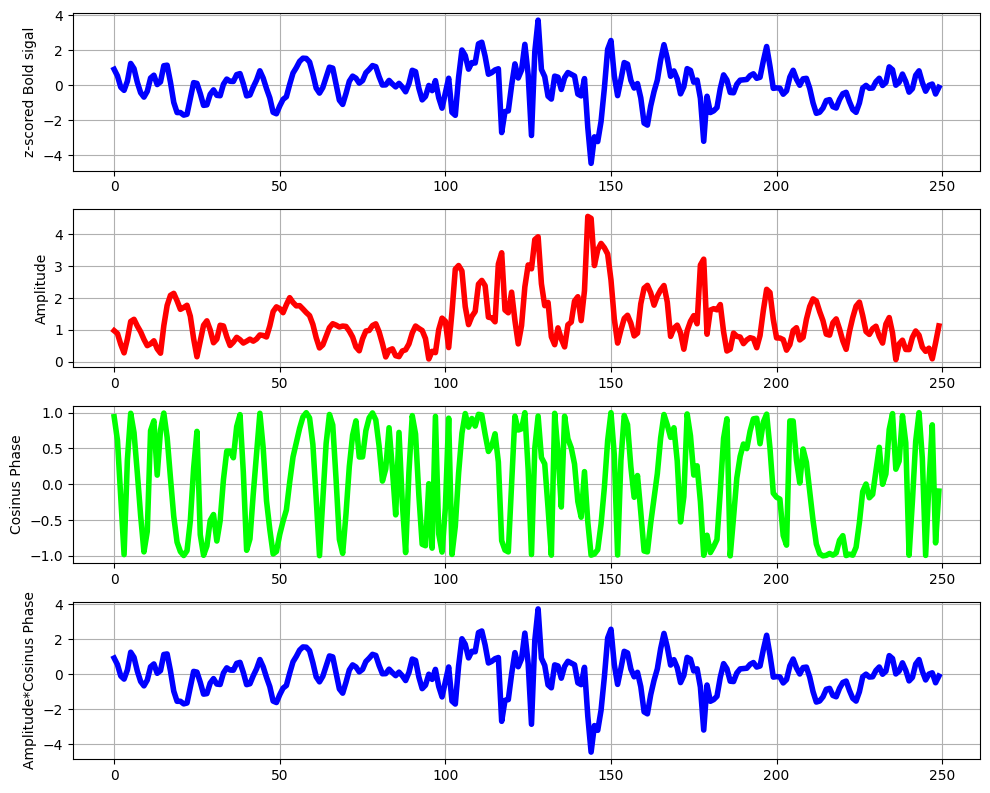

In [11]:
def createfigure(Y1, Y2, Y3, Y4):
    """
    Creates a figure with 4 vertical subplots to visualize:
    - Y1: Z-scored signal (e.g., bold)
    - Y2: Amplitude
    - Y3: Cosine of the phase
    - Y4: Amplitude * cosine of the phase
    """

    fig, axs = plt.subplots(4, 1, figsize=(10, 8))
    
    axs[0].plot(Y1, linewidth=4, color=[0, 0, 1])
    axs[0].set_ylabel('z-scored Bold sigal')
    axs[0].grid(True) 
    
    axs[1].plot(Y2, linewidth=4, color=[1, 0, 0])
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True)
    
    
    axs[2].plot(Y3, linewidth=4, color=[0, 1, 0])
    axs[2].set_ylabel('Cosinus Phase')
    axs[2].grid(True)
    
    axs[3].plot(Y4, linewidth=4, color=[0, 0, 1])
    axs[3].set_ylabel('Amplitude*Cosinus Phase')
    axs[3].grid(True)
    
    plt.tight_layout()
    plt.show()

#We replicate a signal
Y1 = timeseriedata[0, :250]
Y2 = Amplitude[0, :250]
Y3 = np.cos(Phases[0, :250])
Y4 = Amplitude[0, :250] * np.cos(Phases[0, :250])
createfigure(Y1, Y2, Y3, Y4)

### Vectorized Computation for each time instant 

In [12]:
# Number of pairs (only the lower part of the matrix): ROI*(ROI-1)/2
row_idx, col_idx = np.tril_indices(ROI, k=-1)
sorted_indices = np.lexsort((row_idx, col_idx))
lower_indices_corrected = (row_idx[sorted_indices], col_idx[sorted_indices])


num_pairs = len(lower_indices_corrected[0])
pattern = np.empty((num_pairs, time_length))


# Vectorized computation for each time instant
for t in range(time_length):
    patt = np.empty((ROI, ROI))
    for i in range(ROI):
        for j in range(i):
            patt[i,j] = np.cos(adif(Phases[i,t],Phases[j,t]))
    pattern[:, t] = patt[lower_indices_corrected]
    

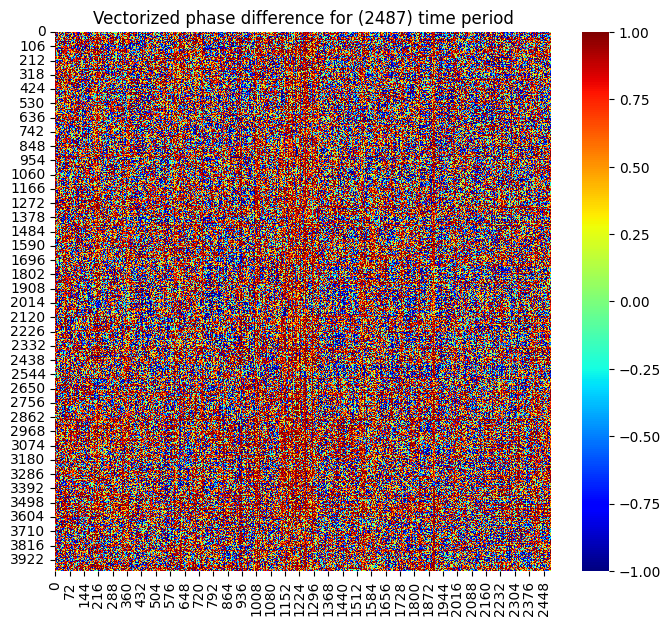

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pattern, cmap='jet', vmin=-1, vmax=1, cbar=True, ax=ax)
ax.set_title(f"Vectorized phase difference for ({time_length}) time period")
plt.show()

### Remove Empty Images

In [14]:
all_pattern2D = pattern.T


# Empty Images
print("Size before removing empty images:", all_pattern2D.shape)
good_pattern = np.sum(np.abs(all_pattern2D), axis=1) > 0
all_pattern2D = all_pattern2D[good_pattern, :]  
print("Size after removing empty images:", all_pattern2D.shape)

# Outliers
# D = squareform(pdist(all_pattern2D, metric='cityblock'))  
# D = zscore(np.mean(D, axis=1))  
# good_pattern = D < 3 
# all_pattern2D = all_pattern2D[good_pattern, :]  
print("Size after removing outliers:", all_pattern2D.shape)


Size before removing empty images: (2487, 4005)
Size after removing empty images: (2487, 4005)
Size after removing outliers: (2487, 4005)


### Convergence Analysis

Running clustering experiments...


Experiments: 100%|██████████| 5/5 [01:19<00:00, 15.95s/it]


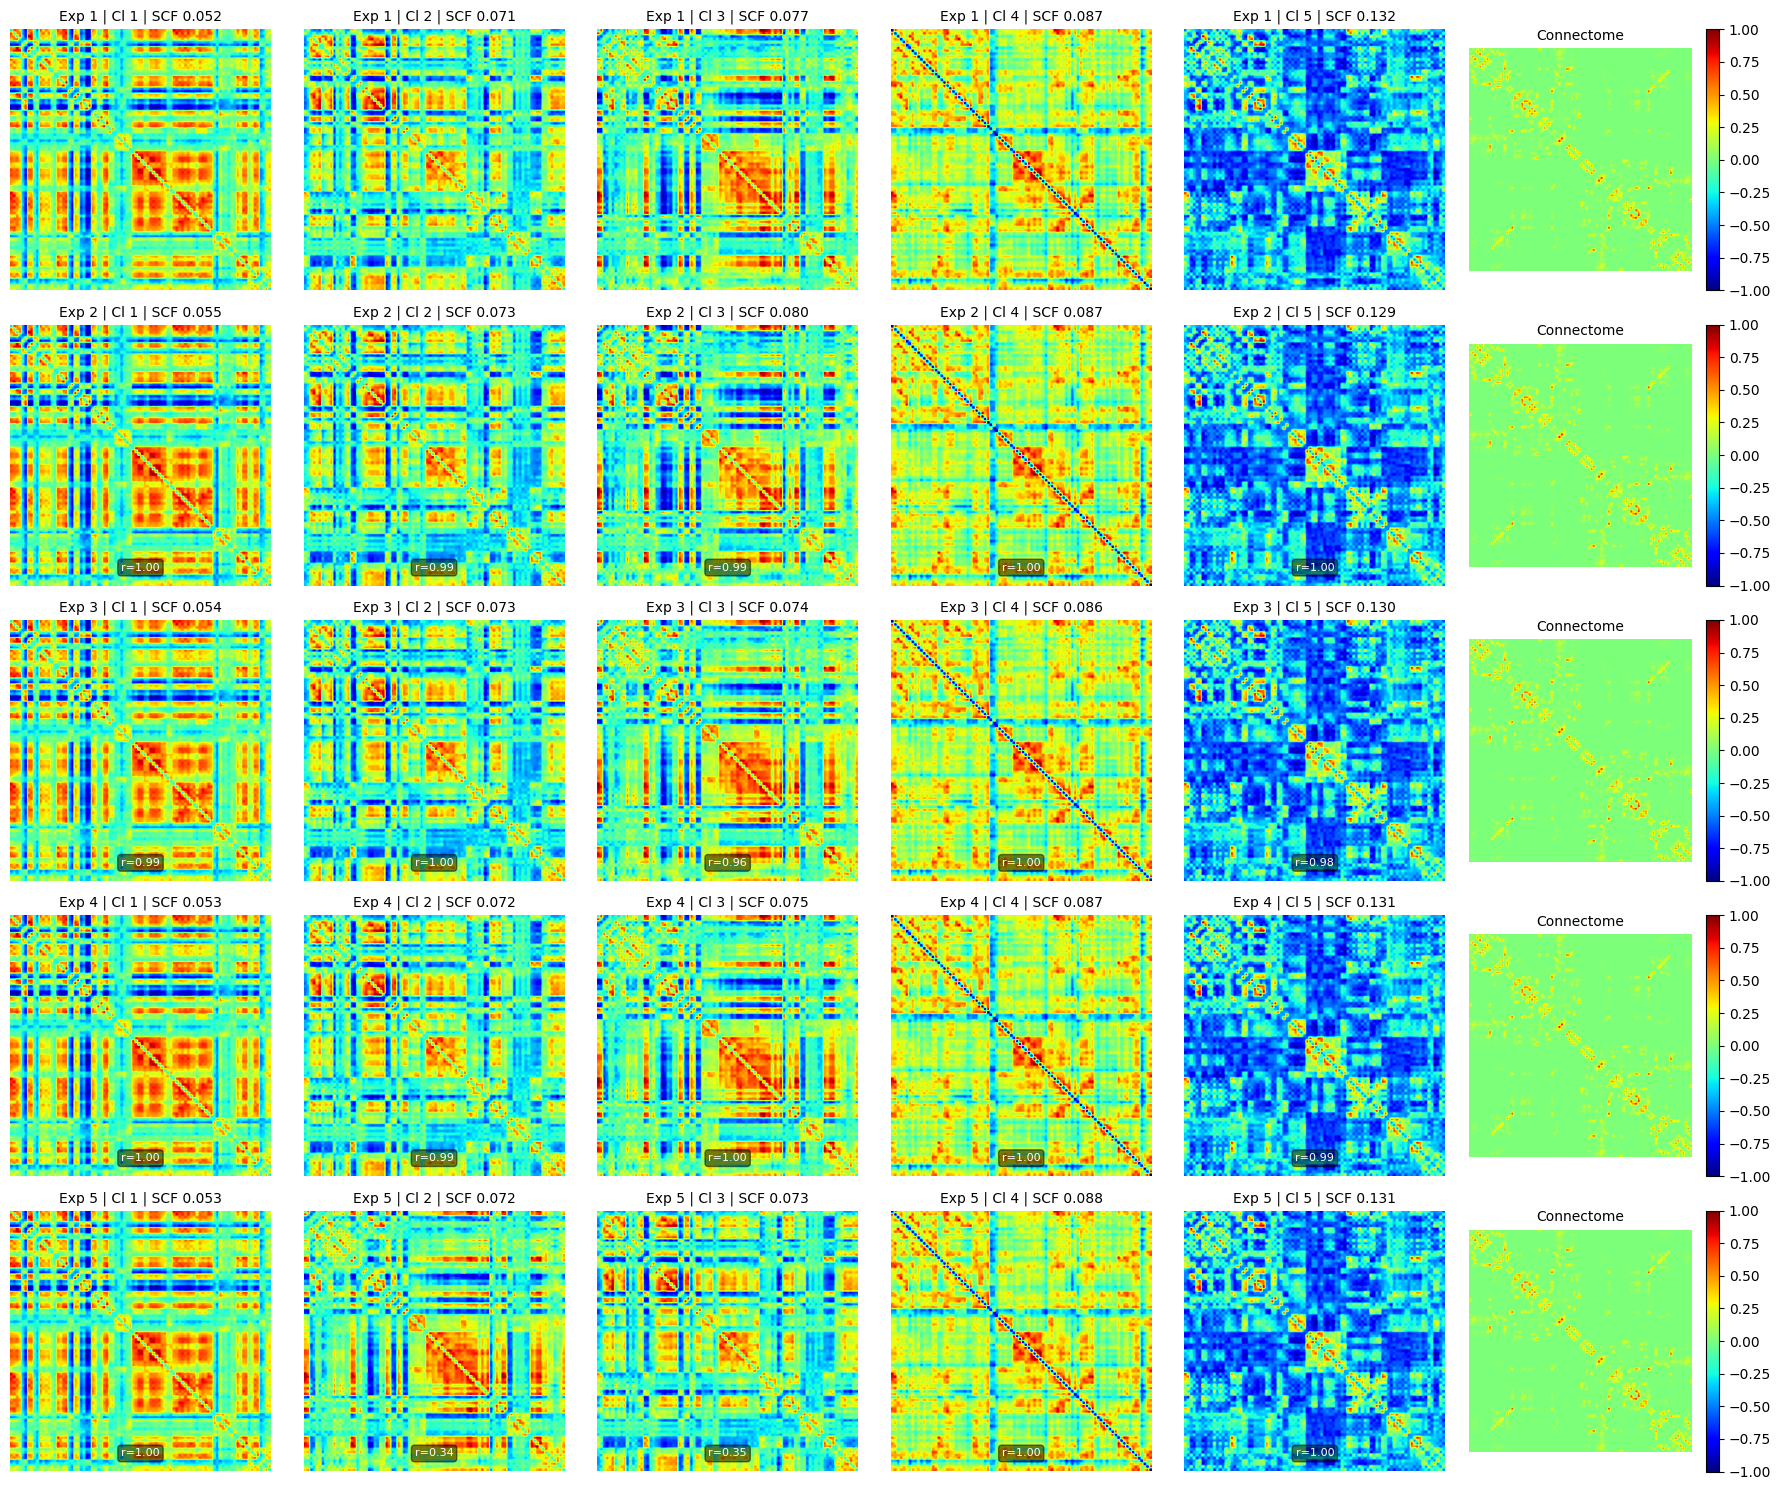

In [17]:
# ------------------------------
# Parameters for Experiments
# ------------------------------
n_clusters = 5        
max_iter = 40  
n_init = 20     
n_experiments = 5

# ------------------------------
# Run the Experiments
# ------------------------------
experiments_results = []
print("Running clustering experiments...")
for exp in tqdm(range(n_experiments), desc="Experiments"):
    kmeans = KMeans(n_clusters=n_clusters, max_iter=max_iter, n_init=n_init, random_state=None)
    kmeans.fit(all_pattern2D)
    experiments_results.append({
        'ctrs_Pha': kmeans.cluster_centers_, 
        'cidx_Pha': kmeans.labels_
    })

# ------------------------------
# Create a n_experiments x (n_clusters + connectome) Grid Plot
# ------------------------------
#fig, axs = plt.subplots(n_experiments, n_clusters, figsize=(n_clusters*3, n_experiments*3))
fig, axs = plt.subplots(n_experiments, n_clusters + 1, figsize=((n_clusters+1)*3, n_experiments*3))

# Flatten the connectome matrix
VC = CC.flatten().astype(np.float64)
sorted_indices = []

for exp in range(n_experiments):
    result = experiments_results[exp]

    CCA = np.zeros(n_clusters)
    for i in range(n_clusters):
        centroid_vector = result['ctrs_Pha'][i, :]
        QQ = squareform(centroid_vector) 
        VA = QQ.flatten()
        MC = np.corrcoef(VA, VC)  # Correlation with the connectome
        CCA[i] = MC[0, 1]

    B = np.sort(CCA)
    I = np.argsort(CCA)
    sorted_indices.append(I)
    
    for cl in range(n_clusters):
        QQ = squareform(result['ctrs_Pha'][I[cl], :])
        im = axs[exp, cl].imshow(QQ, vmin=np.min(QQ), vmax=np.max(QQ), cmap='jet')
        axs[exp, cl].set_title(f"Exp {exp+1} | Cl {cl+1} | SCF {B[cl]:.3f}", fontsize=10)
        axs[exp, cl].axis('off')
        
        # Correlation between experiments
        if exp > 0:
            prev_centroid = experiments_results[exp-1]['ctrs_Pha'][sorted_indices[exp-1][cl], :]
            current_centroid = result['ctrs_Pha'][I[cl], :]
            corr, _ = pearsonr(prev_centroid, current_centroid)
            axs[exp, cl].text(0.5, 0.05, f"r={corr:.2f}", color='white', fontsize=8,
                              ha='center', va='bottom', transform=axs[exp, cl].transAxes,
                              bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))
    
    # Connectome matrix 
    connectome_im = axs[exp, n_clusters].imshow(CC, vmin=-1, vmax=1, cmap='jet')
    axs[exp, n_clusters].set_title("Connectome", fontsize=10)
    axs[exp, n_clusters].axis("off")
    plt.colorbar(connectome_im, ax=axs[exp, n_clusters])

plt.tight_layout()
plt.show()

### K-Means

In [18]:
# Parameters
opts = {"max_iter": 200}
Kmeans_results = {} 

# Manhattan distance
def compute_manhattan_distance(data_point, centroids, cluster_labels):
    return cityblock(data_point, centroids[cluster_labels])

# KMeans clustering for each k (currently just k=5)
for k in [5]:
    kmeans = KMeans(n_clusters=k, max_iter=opts["max_iter"], n_init=1, random_state=0)
    kmeans.fit(all_pattern2D)

    cidx_Pha = kmeans.labels_
    ctrs_Pha = kmeans.cluster_centers_

    #Manhattan distances
    sum_D_Pha = np.sum([compute_manhattan_distance(all_pattern2D[i], ctrs_Pha, cidx_Pha[i]) for i in range(all_pattern2D.shape[0])])

    Kmeans_results[k] = {
        "cidx_Pha": cidx_Pha,
        "ctrs_Pha": ctrs_Pha,
        "sum_D_Pha": sum_D_Pha
    }

# Verify Dimensions
print(f"cidx_Pha shape: {Kmeans_results[5]['cidx_Pha'].shape}")
print(f"ctrs_Pha shape: {Kmeans_results[5]['ctrs_Pha'].shape}")
print(f"sum_D_Pha: {Kmeans_results[5]['sum_D_Pha']}")


cidx_Pha shape: (2487,)
ctrs_Pha shape: (5, 4005)
sum_D_Pha: 5667616.032105358


### Visualization

In [19]:
# AAL Labels
original_labels = [
    "Precentral_L", "Precentral_R", "Frontal_Sup_L", "Frontal_Sup_R",
    "Frontal_Sup_Orb_L", "Frontal_Sup_Orb_R", "Frontal_Mid_L", "Frontal_Mid_R",
    "Frontal_Mid_Orb_L", "Frontal_Mid_Orb_R", "Frontal_Inf_Oper_L", "Frontal_Inf_Oper_R",
    "Frontal_Inf_Tri_L", "Frontal_Inf_Tri_R", "Frontal_Inf_Orb_L", "Frontal_Inf_Orb_R",
    "Rolandic_Oper_L", "Rolandic_Oper_R", "Supp_Motor_Area_L", "Supp_Motor_Area_R",
    "Olfactory_L", "Olfactory_R", "Frontal_Sup_Medial_L", "Frontal_Sup_Medial_R",
    "Frontal_Mid_Orb_L", "Frontal_Mid_Orb_R", "Rectus_L", "Rectus_R", "Insula_L", "Insula_R",
    "Cingulum_Ant_L", "Cingulum_Ant_R", "Cingulum_Mid_L", "Cingulum_Mid_R",
    "Cingulum_Post_L", "Cingulum_Post_R", "Hippocampus_L", "Hippocampus_R",
    "ParaHippocampal_L", "ParaHippocampal_R", "Amygdala_L", "Amygdala_R",
    "Calcarine_L", "Calcarine_R", "Cuneus_L", "Cuneus_R", "Lingual_L", "Lingual_R",
    "Occipital_Sup_L", "Occipital_Sup_R", "Occipital_Mid_L", "Occipital_Mid_R",
    "Occipital_Inf_L", "Occipital_Inf_R", "Fusiform_L", "Fusiform_R",
    "Postcentral_L", "Postcentral_R", "Parietal_Sup_L", "Parietal_Sup_R",
    "Parietal_Inf_L", "Parietal_Inf_R", "SupraMarginal_L", "SupraMarginal_R",
    "Angular_L", "Angular_R", "Precuneus_L", "Precuneus_R",
    "Paracentral_Lobule_L", "Paracentral_Lobule_R", "Caudate_L", "Caudate_R",
    "Putamen_L", "Putamen_R", "Pallidum_L", "Pallidum_R", "Thalamus_L", "Thalamus_R",
    "Heschl_L", "Heschl_R", "Temporal_Sup_L", "Temporal_Sup_R",
    "Temporal_Pole_Sup_L", "Temporal_Pole_Sup_R", "Temporal_Mid_L", "Temporal_Mid_R",
    "Temporal_Pole_Mid_L", "Temporal_Pole_Mid_R", "Temporal_Inf_L", "Temporal_Inf_R"
]

# Anatomical Groups
anatomical_groups = {
    "Cingulate": ["Cingulum_Ant_L", "Cingulum_Ant_R", "Cingulum_Mid_L", "Cingulum_Mid_R", "Cingulum_Post_L", "Cingulum_Post_R"],
    "Frontal": ["Frontal_Sup_L", "Frontal_Sup_R", "Frontal_Sup_Orb_L", "Frontal_Sup_Orb_R",
                "Frontal_Mid_L", "Frontal_Mid_R", "Frontal_Mid_Orb_L", "Frontal_Mid_Orb_R",
                "Frontal_Inf_Oper_L", "Frontal_Inf_Oper_R", "Frontal_Inf_Tri_L", "Frontal_Inf_Tri_R",
                "Frontal_Inf_Orb_L", "Frontal_Inf_Orb_R", "Supp_Motor_Area_L", "Supp_Motor_Area_R",
                "Olfactory_L", "Olfactory_R", "Frontal_Sup_Medial_L", "Frontal_Sup_Medial_R", "Rectus_L", "Rectus_R"],
    "Limbic": ["Hippocampus_L", "Hippocampus_R", "ParaHippocampal_L", "ParaHippocampal_R", "Amygdala_L", "Amygdala_R"],
    "Occipital": ["Calcarine_L", "Calcarine_R", "Cuneus_L", "Cuneus_R", "Lingual_L", "Lingual_R",
                  "Occipital_Sup_L", "Occipital_Sup_R", "Occipital_Mid_L", "Occipital_Mid_R",
                  "Occipital_Inf_L", "Occipital_Inf_R", "Fusiform_L", "Fusiform_R"],
    "Parietal": ["Parietal_Sup_L", "Parietal_Sup_R", "Parietal_Inf_L", "Parietal_Inf_R",
                 "SupraMarginal_L", "SupraMarginal_R", "Angular_L", "Angular_R",
                 "Precuneus_L", "Precuneus_R", "Paracentral_Lobule_L", "Paracentral_Lobule_R"],
    "Sensorimotor": ["Precentral_L", "Precentral_R", "Postcentral_L", "Postcentral_R", "Rolandic_Oper_L", "Rolandic_Oper_R"],
    "Subcortical": ["Caudate_L", "Caudate_R", "Putamen_L", "Putamen_R", "Pallidum_L", "Pallidum_R", "Thalamus_L", "Thalamus_R"],
    "Temporal": ["Insula_L", "Insula_R", "Heschl_L", "Heschl_R", "Temporal_Sup_L", "Temporal_Sup_R",
                 "Temporal_Pole_Sup_L", "Temporal_Pole_Sup_R", "Temporal_Mid_L", "Temporal_Mid_R",
                 "Temporal_Pole_Mid_L", "Temporal_Pole_Mid_R", "Temporal_Inf_L", "Temporal_Inf_R"]
}

def create_brain_chord_diagram(correlation_matrix,name,threshold=0.8):
    """
    Create a circular chord diagram for a 90x90 brain correlation matrix.
    
    Parameters:
    - correlation_matrix: 90x90 numpy array of correlations
    """
    # Validate input
    if correlation_matrix.shape != (90, 90):
        raise ValueError("Correlation matrix must be 90x90")
    
    # Ensure symmetric matrix (correlation matrices should be symmetric)
    correlation_matrix = np.abs(correlation_matrix)  # Use absolute values
    
    # Reorder matrix
    new_order = []
    new_order_labels = []

    # Assign regions to their anatomical groups
    for group_name, group_regions in anatomical_groups.items():
        for region in group_regions:
            if region in original_labels and region not in new_order:
                new_order.append(region)
                new_order_labels.append(group_name)

    # Add any remaining regions not in an anatomical group
    for region in original_labels:
        if region not in new_order:
            new_order.append(region)
            new_order_labels.append("Other")

    # Find the indices of new_order regions in original_labels
    indices = [original_labels.index(region) for region in new_order]

    # Reorder the connectivity matrix based on the new order
    reordered_matrix = correlation_matrix[np.ix_(indices, indices)]
    
    # Determine unique groups and their order
    unique_groups = list(dict.fromkeys(new_order_labels))
    num_groups = len(unique_groups)
    
    # Calculate group boundaries
    group_boundaries = []
    current_start = 0
    for group in unique_groups:
        group_indices = [i for i, label in enumerate(new_order_labels) if label == group]
        group_boundaries.append((current_start, current_start + len(group_indices) - 1, group))
        current_start += len(group_indices)
    
    # Calculate group connectivity
    group_connectivity = np.zeros((num_groups, num_groups))
    for i in range(num_groups):
        start_i, end_i = group_boundaries[i][0], group_boundaries[i][1]
        for j in range(num_groups):
            start_j, end_j = group_boundaries[j][0], group_boundaries[j][1]
            
            # Extract submatrix
            submatrix = reordered_matrix[start_i:end_i+1, start_j:end_j+1]
            
            # Calculate average connectivity
            if i == j:
                # Exclude diagonal for self-connections
                mask = ~np.eye(submatrix.shape[0], dtype=bool)
                group_connectivity[i, j] = np.mean(submatrix[mask]) if mask.sum() > 0 else 0
            else:
                group_connectivity[i, j] = np.mean(submatrix)
    
    # Normalize connectivity
    group_connectivity /= np.max(np.abs(group_connectivity))
    
    # Color map for anatomical groups
    group_colors = np.array([
        [0.2, 0.6, 0.4],   # Cingulate - Green
        [0.9, 0.7, 0.1],   # Frontal - Yellow
        [0.7, 0.2, 0.5],   # Limbic - Purple
        [0.1, 0.4, 0.8],   # Occipital - Blue
        [0.4, 0.7, 0.3],   # Parietal - Light Green
        [0.9, 0.3, 0.2],   # Sensorimotor - Red
        [0.5, 0.5, 0.5],   # Subcortical - Gray
        [0.9, 0.5, 0.1],   # Temporal - Orange
        [0.7, 0.7, 0.7]    # Other - Light Gray
    ])
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=(5, 5))

    # Calculate arc positions
    group_sizes = np.array([sum(1 for label in new_order_labels if label == group) for group in unique_groups])
    total_regions = np.sum(group_sizes)
    arc_lengths = group_sizes / total_regions * 2 * np.pi
    
    # Calculate start and end angles
    start_angles = np.cumsum(np.concatenate(([0], arc_lengths[:-1])))
    end_angles = start_angles + arc_lengths
    
    # Rotate to put first group at the top
    start_angles -= np.pi/2
    end_angles -= np.pi/2
    
    # Plot arcs for each anatomical group
    inner_radius, outer_radius = 0.8, 1.0
    for i in range(num_groups):
        # Create arc
        arc_theta = np.linspace(start_angles[i], end_angles[i], 50)
        
        x_inner = inner_radius * np.cos(arc_theta)
        y_inner = inner_radius * np.sin(arc_theta)
        x_outer = outer_radius * np.cos(arc_theta)
        y_outer = outer_radius * np.sin(arc_theta)
        
        # Fill arc
        color_idx = i % len(group_colors)
        ax.fill(np.concatenate([x_inner, x_outer[::-1]]),
                 np.concatenate([y_inner, y_outer[::-1]]),
                 color=group_colors[color_idx],
                 alpha=0.7,
                 edgecolor='none')
        
        # Add group label
        mid_angle = (start_angles[i] + end_angles[i]) / 2
        label_radius = 1.1
        label_x = label_radius * np.cos(mid_angle)
        label_y = label_radius * np.sin(mid_angle)
        
        # Determine text alignment
        if label_x > 0 and label_y > 0:  # Quadrant 1
            ha, va = 'left', 'bottom'
            rotation = mid_angle * 180/np.pi - 90
        elif label_x < 0 and label_y > 0:  # Quadrant 2
            ha, va = 'right', 'bottom'
            rotation = mid_angle * 180/np.pi + 90
        elif label_x < 0 and label_y < 0:  # Quadrant 3
            ha, va = 'right', 'top'
            rotation = mid_angle * 180/np.pi + 90
        else:  # Quadrant 4
            ha, va = 'left', 'top'
            rotation = mid_angle * 180/np.pi - 90
        
        ax.text(label_x, label_y, unique_groups[i],
                 fontweight='bold',
                 horizontalalignment=ha,
                 verticalalignment=va,
                 rotation=rotation)
    
    # Draw chords between groups
    for i in range(num_groups):
        for j in range(num_groups):
            if abs(group_connectivity[i, j]) > threshold:
                # Calculate mid angles
                mid_angle_i = (start_angles[i] + end_angles[i]) / 2
                mid_angle_j = (start_angles[j] + end_angles[j]) / 2
                
                # Calculate starting points
                x1 = inner_radius * np.cos(mid_angle_i)
                y1 = inner_radius * np.sin(mid_angle_i)
                x2 = inner_radius * np.cos(mid_angle_j)
                y2 = inner_radius * np.sin(mid_angle_j)
                
                # Control points
                ctrl_radius = 0.5
                ctrl_x1 = ctrl_radius * np.cos(mid_angle_i)
                ctrl_y1 = ctrl_radius * np.sin(mid_angle_i)
                ctrl_x2 = ctrl_radius * np.cos(mid_angle_j)
                ctrl_y2 = ctrl_radius * np.sin(mid_angle_j)
                
                # Bezier curve calculation
                t = np.linspace(0, 1, 50)
                curve_x = (1-t)**3 * x1 + 3*(1-t)**2 * t * ctrl_x1 + 3*(1-t) * t**2 * ctrl_x2 + t**3 * x2
                curve_y = (1-t)**3 * y1 + 3*(1-t)**2 * t * ctrl_y1 + 3*(1-t) * t**2 * ctrl_y2 + t**3 * y2
                
                # Line properties
                conn_strength = abs(group_connectivity[i, j])
                line_width = 1 + 4 * conn_strength
                
                # Color blending
                color_i = group_colors[i % len(group_colors)]
                color_j = group_colors[j % len(group_colors)]
                
                chord_color = (color_i + color_j) / 2
                alpha_val = 0.5 * conn_strength
                
                # Plot chord
                ax.plot(curve_x, curve_y, color=np.concatenate([chord_color, [alpha_val]]), linewidth=line_width)
    
    
    ax.axis('equal')
    ax.axis('off')
    ax.set_title(name)
    return fig

In [20]:
# Clustering States
n_state = 5
cidx = Kmeans_results[n_state]['cidx_Pha'] 
L = cidx.shape[0]
T_shift = 9


id_aal = np.arange(1, 91) 
id_deco = np.concatenate([np.linspace(1, 89, 45, dtype=int), np.linspace(2, 90, 45, dtype=int)[::-1]])
deco_to_aal_mapping = np.searchsorted(id_aal, id_deco)  
CC2 = CC[np.ix_(deco_to_aal_mapping, deco_to_aal_mapping)] 
VC = CC.flatten().astype(np.float64)



# Compute correlations between centroids and connectome
CCA = np.zeros(n_state)
for i in range(n_state):
    centroid_vector = Kmeans_results[n_state]['ctrs_Pha'][i, :]
    QQ = squareform(centroid_vector) 
    VA = QQ.flatten()
    MC = np.corrcoef(VA, VC)  # Correlation with the connectome
    CCA[i] = MC[0, 1]

B = np.sort(CCA)
I = np.argsort(CCA)


rate = np.zeros(n_state)
ratea = np.zeros(n_state)
rateb = np.zeros(n_state)

denom = L - 2 * T_shift 
mid = len(cidx) // 2  #We concatenated 2 time series (drug + placebo)


for bst in range(n_state):
    rate[bst]  = np.sum(cidx == I[bst]) / denom
    ratea[bst] = np.sum(cidx[:mid] == I[bst]) / denom
    rateb[bst] = np.sum(cidx[mid:] == I[bst]) / denom


# Compute cumulative time spent per subject
times_matrix_k = np.zeros((num, 2))
times_matrix_p = np.zeros((num, 2))

for idx, i in enumerate(num_patients):
    size_value_k = data_PSILO[i]['TS_Psilo'].shape[1]
    size_value_p = data_PSILO[i]['TS_PCB'].shape[1]

    times_matrix_k[idx, 0] = size_value_k
    times_matrix_p[idx, 0] = size_value_p

    times_matrix_k[idx, 1] = size_value_k if idx == 0 else times_matrix_k[idx-1, 1] + size_value_k
    times_matrix_p[idx, 1] = size_value_p if idx == 0 else times_matrix_p[idx-1, 1] + size_value_p

scratekt = np.zeros((num, n_state))
scratektp = np.zeros((num, n_state))

for s in range(num):
    for j in range(n_state):
        if s == 0:
            scratekt[s, j] = np.sum(cidx[:int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226:1226 + int(times_matrix_p[s, 1])] == I[j]) / times_matrix_p[s, 1]
        else:
            scratekt[s, j] = np.sum(cidx[int(times_matrix_k[s-1, 1]):int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226 + int(times_matrix_p[s-1, 1]): 1226 + int(times_matrix_p[s, 1]) - 20] == I[j]) / times_matrix_p[s, 1]


CH = np.zeros((num * 2, n_state))

for i in range(n_state):
    CH[:, i] = np.concatenate([scratekt[:, i], scratektp[:, i]])

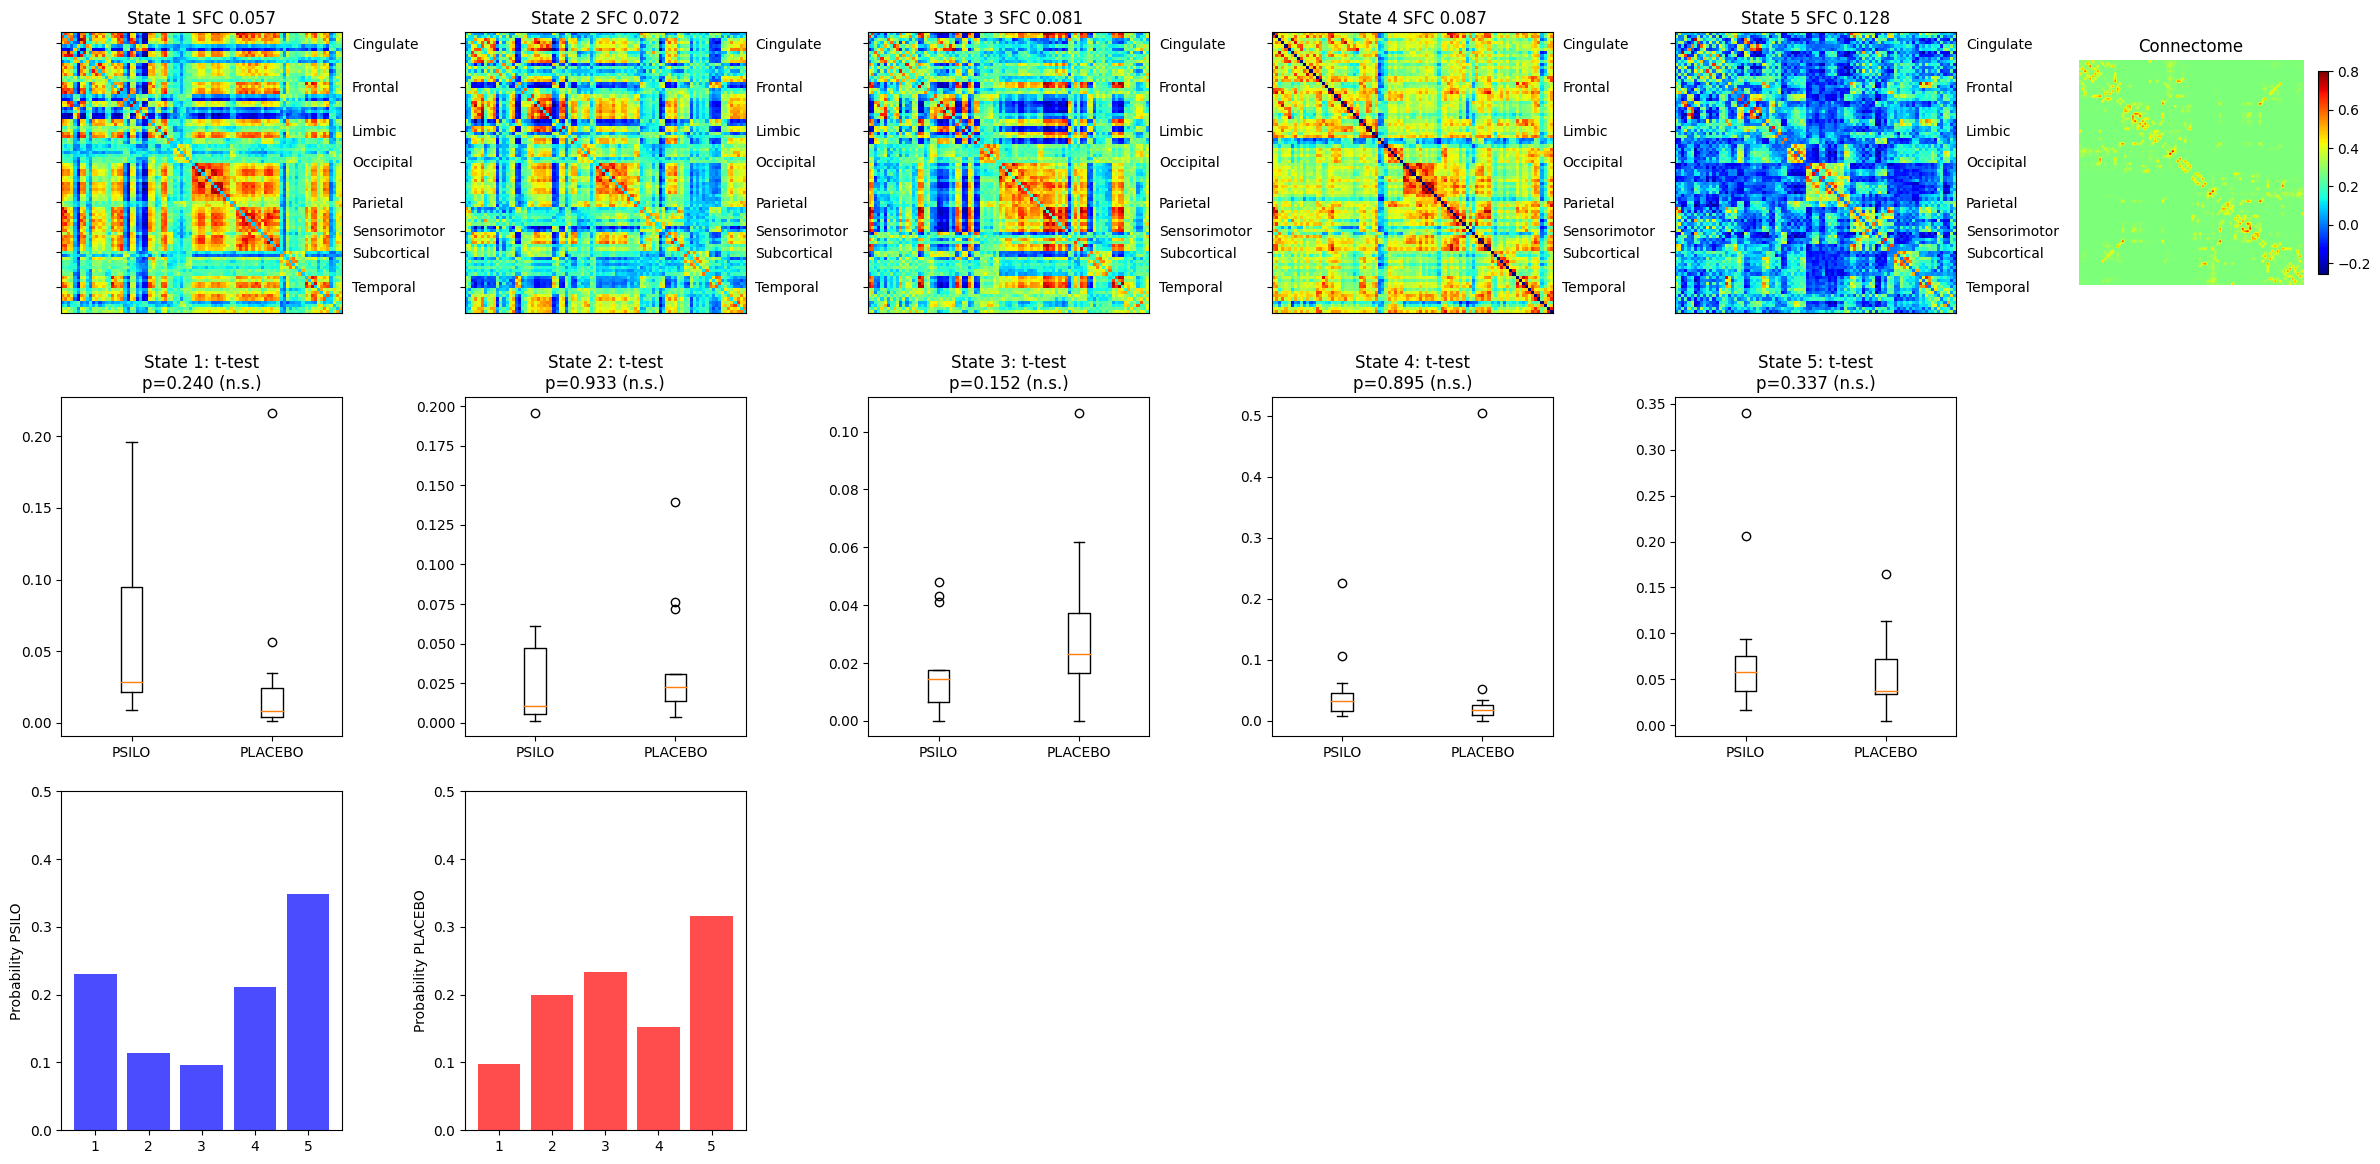

In [21]:
fig, axs = plt.subplots(3, n_state + 1, figsize=(4*(n_state+1), 12))

#Correlation matrices of each state

#Normalizar por plot (Su rango)**
for i in range(n_state):
    QQ = squareform(Kmeans_results[n_state]['ctrs_Pha'][I[i], :])

    labels = reorder_matrix(QQ)[2] 
    unique_labels, indices = np.unique(labels, return_index=True)
    centers = [(indices[j] + (indices[j+1] if j+1 < len(indices) else len(labels))) / 2 for j in range(len(indices))]
    im = axs[0, i].imshow(QQ, vmin=np.min(QQ), vmax=np.max(QQ), cmap='jet')
    axs[0, i].set_title(f"State {i+1} SFC {B[i]:.3f}")
    axs[0,i].set_yticks(centers)
    axs[0,i].set_yticklabels(unique_labels)
    axs[0,i].tick_params(axis="y", labelright=True, labelleft=False)
    axs[0,i].set_xticks([]) 
    axs[0,i].tick_params(axis="x", which="both", bottom=False, top=False)  

#Connectome matrix
axs[0, n_state].imshow(CC, vmin=-1, vmax=1, cmap='jet')
axs[0, n_state].set_title("Connectome")
axs[0, n_state].axis("off")
plt.colorbar(im, ax=axs[0, n_state], shrink=0.6)

#Boxplots for each state with statistical test
alpha = 0.1

for i in range(n_state):
    # Extract data for the two groups
    psilo_data = CH[:num, i]
    placebo_data = CH[num:, i]
    
    # Perform Shapiro-Wilk test to check for normality
    _, p_psilo = stats.shapiro(psilo_data)
    _, p_placebo = stats.shapiro(placebo_data)
    
    # Determine which test to use based on normality
    # if p_psilo > 0.05 and p_placebo > 0.05:
        # Both distributions are normal, use t-test
    _, p_value = stats.ttest_ind(psilo_data, placebo_data, equal_var=False)
    test_name = "t-test"
    # else:
    #     # At least one distribution is not normal, use Mann-Whitney U test
    #     _, p_value = stats.mannwhitneyu(psilo_data, placebo_data)
    #    test_name = "M-W"
    
    # Create boxplot
    axs[1, i].boxplot([psilo_data, placebo_data], labels=["PSILO", "PLACEBO"])
    
    # Add statistical test result to the plot
    significance = "sig" if p_value < alpha else "n.s."
    axs[1, i].set_title(f"State {i+1}: {test_name}\np={p_value:.3f} ({significance})")
    
    # Add horizontal line to show significance
    if p_value < alpha:
        y_max = max(np.max(psilo_data), np.max(placebo_data))
        y_pos = y_max * 1.1
        axs[1, i].plot([1, 2], [y_pos, y_pos], 'k-')
        axs[1, i].text(1.5, y_pos * 1.05, '*', ha='center', va='bottom', fontsize=12)

axs[1, n_state].axis('off')

#Bar plots for state probabilities in MDMA and PLACEBO
axs[2, 0].bar(np.arange(1, n_state+1), ratea/np.sum(ratea), color='blue', alpha=0.7)
axs[2, 0].set_ylim([0, 0.5])
axs[2, 0].set_ylabel('Probability PSILO')

axs[2, 1].bar(np.arange(1, n_state+1), rateb/np.sum(rateb), color='red', alpha=0.7)
axs[2, 1].set_ylim([0, 0.5])
axs[2, 1].set_ylabel('Probability PLACEBO')

# Hide remaining columns
for j in range(2, n_state+1):
    axs[2, j].axis('off')

plt.tight_layout()
plt.show()

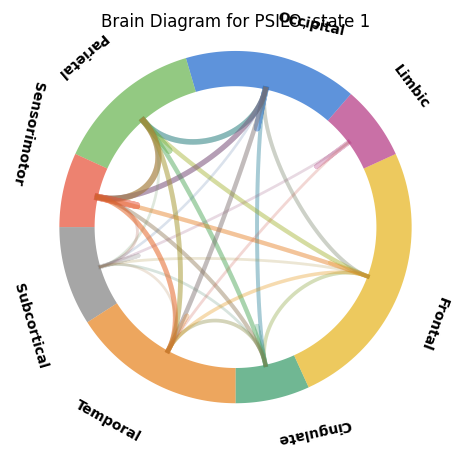

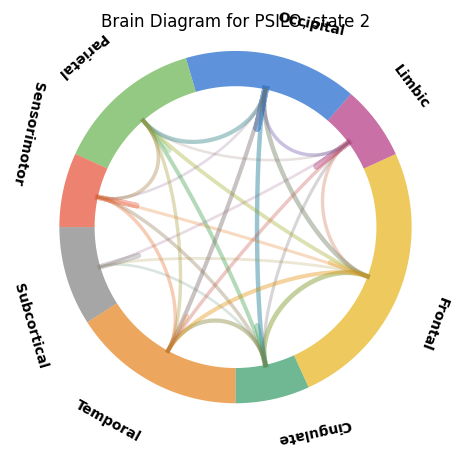

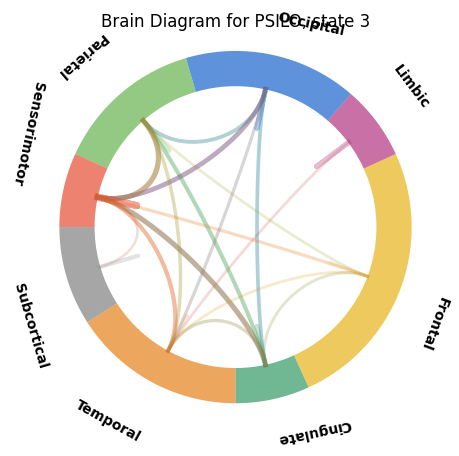

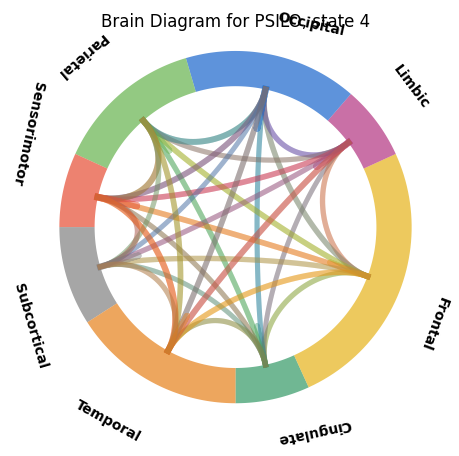

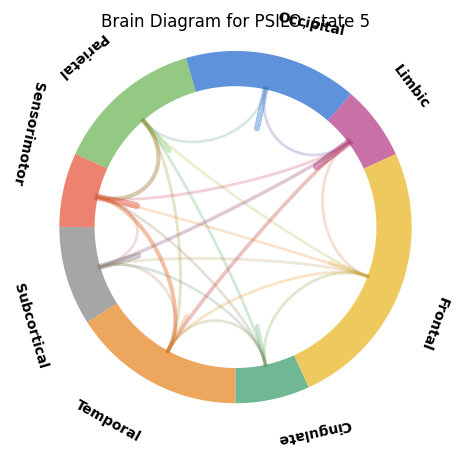

In [22]:
# Calculate and visualize correlation matrices for each state
correlation_matrices = {}

# Calculate correlation matrices for all states
for i in range(n_state):
    state_matrix = squareform(Kmeans_results[n_state]['ctrs_Pha'][I[i], :])
    correlation_matrices[i] = state_matrix
    
# Create brain chord diagrams for each state
threshold = 0.20
for state, matrix in correlation_matrices.items():
    diagram_title = f"Brain Diagram for PSILO, state {state+1}"
    create_brain_chord_diagram(matrix, diagram_title, threshold=threshold)

In [ ]:
# We plot all the correlation matrix even there's corrupted data
num_patients=data_PSILO["TS_Psilo"].shape[0]


fig, axs = plt.subplots(int(np.ceil(num_patients / 3)), 3, figsize=(12, 15))

#Time Series Psilo
corr_mats = [np.corrcoef(data_PSILO['TS_Psilo'][k].T) for k in range(num_patients)]
all_corr_values = np.concatenate([corr_mat.flatten() for corr_mat in corr_mats])
min_val, max_val = np.min(all_corr_values), np.max(all_corr_values)


#Plots
for k, corr_mat in enumerate(corr_mats):
    row = k // 3  
    col = k % 3
    ax = axs[row, col]
    
    # Mostrar la matriz de correlación
    im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
    ax.axis("off")
    ax.set_title(f"PSILO_FC {range(num_patients)[k]+1}") 

for k in range(num, int(np.ceil(num / 3) * 3)):
    row = k // 3
    col = k % 3
    axs[row, col].axis('off')


fig.suptitle('Correlation Matrices from TS_Psilo', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=cbar_ax, label='Correlation Coefficient')
plt.show()

In [ ]:
# We plot all the correlation matrix even there's corrupted data
num_patients=data_PSILO["TS_PCB"].shape[0]


fig, axs = plt.subplots(int(np.ceil(num_patients / 3)), 3, figsize=(12, 15))

#Time Series Psilo
corr_mats = [np.corrcoef(data_PSILO['TS_PCB'][k].T) for k in range(num_patients)]
all_corr_values = np.concatenate([corr_mat.flatten() for corr_mat in corr_mats])
min_val, max_val = np.min(all_corr_values), np.max(all_corr_values)


#Plots
for k, corr_mat in enumerate(corr_mats):
    row = k // 3  
    col = k % 3
    ax = axs[row, col]
    
    # Mostrar la matriz de correlación
    im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
    ax.axis("off")
    ax.set_title(f"PSILO_FC {range(num_patients)[k]+1}") 

for k in range(num, int(np.ceil(num / 3) * 3)):
    row = k // 3
    col = k % 3
    axs[row, col].axis('off')


fig.suptitle('Correlation Matrices from TS_PCB', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=cbar_ax, label='Correlation Coefficient')
plt.show()